In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score

In [24]:
load_diabetes

<function sklearn.datasets._base.load_diabetes(*, return_X_y=False, as_frame=False, scaled=True)>

In [25]:
df=load_diabetes(as_frame=True).frame

In [26]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [27]:
df.shape

(442, 11)

In [28]:
X=df.drop("target",axis=1)
y=df["target"]

In [29]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [30]:
param_grid = {
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10, 15],
    'ccp_alpha': [0.0, 0.01, 0.05, 0.1, 0.5]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)


Best Parameters: {'ccp_alpha': 0.0, 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best CV Score: 0.3079300638666279


C:\Users\abbur\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [38]:
from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor(max_depth=7,min_samples_leaf=20)
model.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=7, min_samples_leaf=20)

In [39]:
from sklearn.metrics import r2_score,mean_squared_error
y_pred_train=model.predict(X_train)
y_pred_test=model.predict(X_test)
print("mse error",mean_squared_error(y_train,y_pred_train))

print("mse error",mean_squared_error(y_test,y_pred_test))

print("r2 score",r2_score(y_train,y_pred_train))
print("r2 score",r2_score(y_test,y_pred_test))
      

mse error 2795.7093704335157
mse error 3177.664925233041
r2 score 0.5452860742356658
r2 score 0.41135906558189406


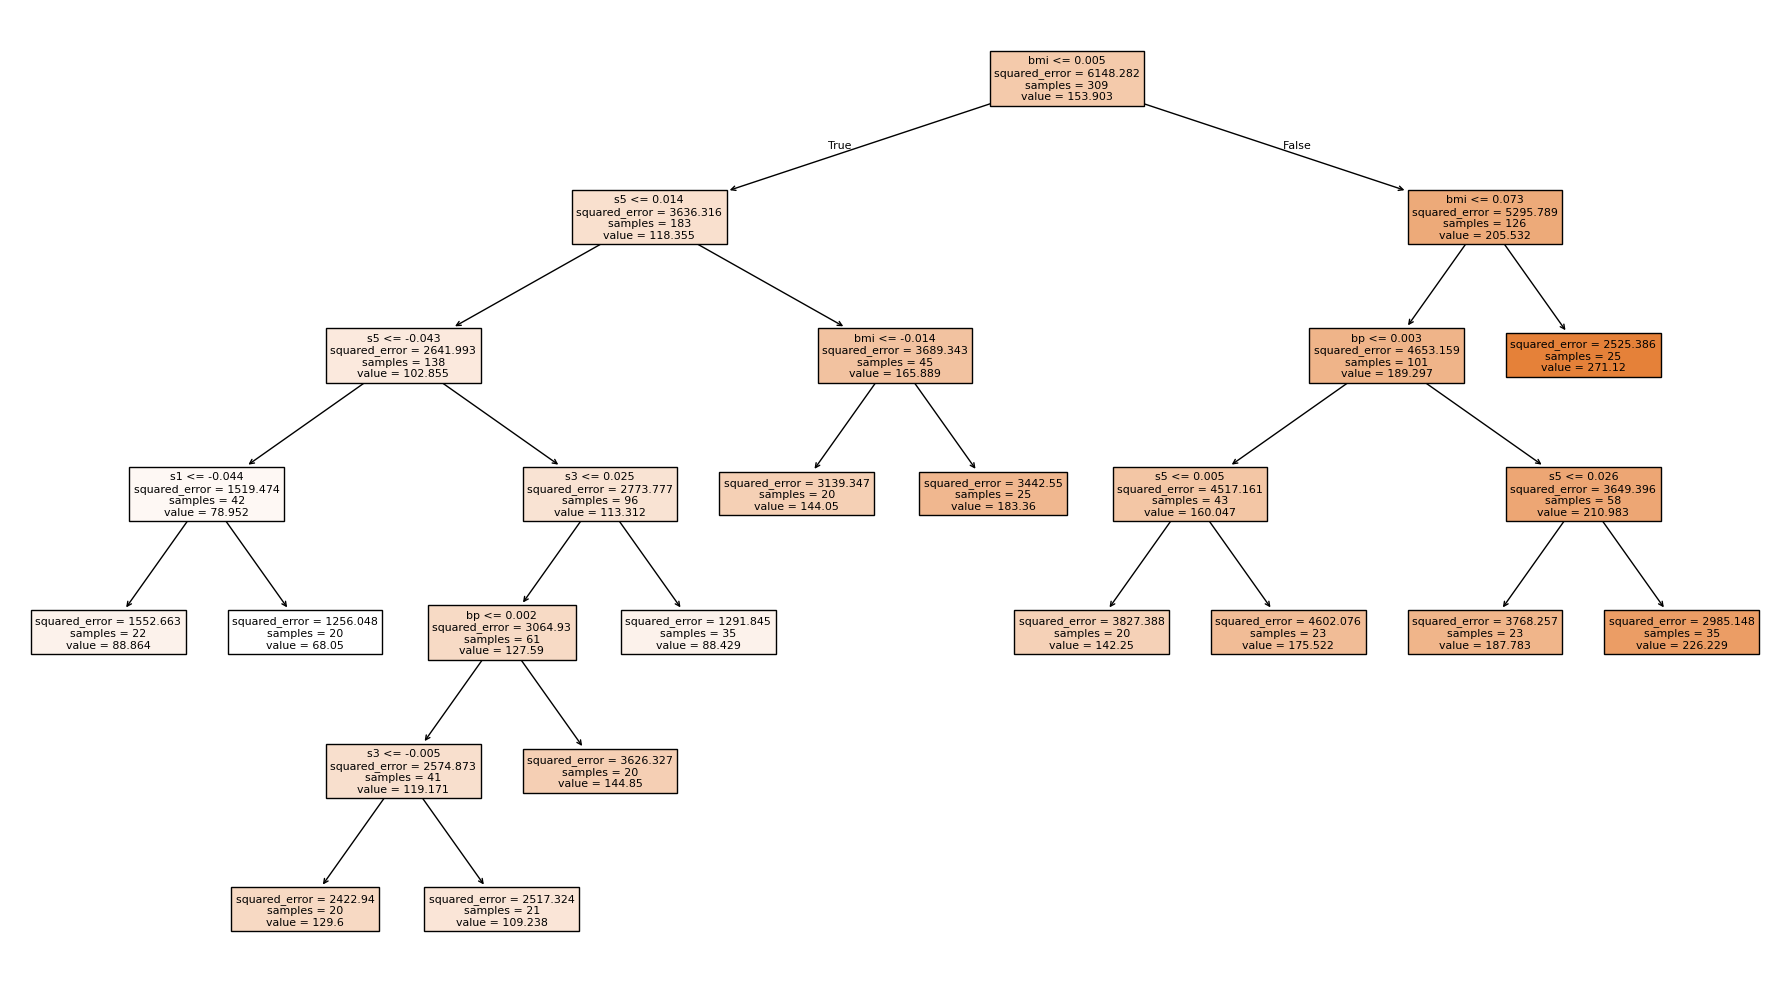

In [40]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True
)
plt.tight_layout()
plt.show()